# Clustering Task – Country Wealth Ecosystem Classification

## Objective

Group countries into structural archetypes based on the composition of their billionaire populations:

| Archetype | Description |
|---|---|
| **Innovation Ecosystem** | High tech/service sectors, high self-made ratio, diversified industry, high education |
| **Rentier Paradise** | High finance/real-estate, high inherited wealth, low sectoral diversity |
| **Extraction Economy** | High energy/mining sectors, resource-dependent, low self-made ratio |

## Three algorithms applied

| Algorithm | Persona | Key capability |
|---|---|---|
| **K-Means** | Persona 1 | Partitional clustering, k=3 aligned with theory |
| **DBSCAN** | Persona 2 | Detects atypical countries (outliers) with no forced assignment |
| **Hierarchical Ward** | Persona 2 | Full dendrogram showing how countries naturally split |

**Internal metrics compared:** Silhouette Score · Davies-Bouldin Index · Calinski-Harabasz Index

---
**Group Members:**
- Anna Martina Visone – avisone@unal.edu.co
- Nicolás Martínez López – nmartinezl@unal.edu.co
- Miller Estiven Barrera Gonzalez – mbarrerag@unal.edu.co
- Sergio Andres Castro Vargas – secastrov@unal.edu.co

**Universidad Nacional de Colombia – Sede Bogotá**

# 1. Libraries

In [1]:
%pip install -q scikit-learn matplotlib seaborn scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='tab10')
print('Libraries loaded ✓')

Libraries loaded ✓


# 2. Load and inspect raw data

In [3]:
dataset_url = "https://raw.githubusercontent.com/nmart1nezl/DataMiningProject/refs/heads/main/datasets/dataset_cleaned.csv"
df = pd.read_csv(dataset_url)
df.head()

,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,selfMade,...,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,associated_companies,number_of_companies
0,211000,Fashion & Retail,Bernard Arnault & family,74.080767,France,Paris,Retail and Consumer Goods,Consumer Discretionary,France,False,...,1.1,2.715518e+12,65.6,102.5,82.5,24.2,60.7,67059887.0,"LVMH (Louis Vuitton, Dior, Givenchy, Tiffany &...",75
1,180000,Automotive,Elon Musk,51.767283,United States,Austin,Technology,Consumer Discretionary,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Tesla, SpaceX, X (Twitter), Starlink, The Bori...",7
2,114000,Technology,Jeff Bezos,59.225188,United States,Medina,Technology,Technology & Telecommunications,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Amazon, Blue Origin, The Washington Post, Bezo...",100
3,107000,Technology,Larry Ellison,78.628337,United States,Lanai,Technology,Technology & Telecommunications,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Oracle, Tesla (stake), NetSuite, Sensei Ag, Pa...",5
4,106000,Finance & Investments,Warren Buffett,92.594114,United States,Omaha,Finance and Investments,Financials & Investments,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Berkshire Hathaway (GEICO, Duracell, Dairy Que...",60


In [4]:
df['industries'].head(15)

,industries
0,Consumer Discretionary
1,Consumer Discretionary
2,Technology & Telecommunications
3,Technology & Telecommunications
4,Financials & Investments
5,Technology & Telecommunications
6,"Media, Entertainment & Leisure"
7,Technology & Telecommunications
8,Other
9,Technology & Telecommunications


# 3. Feature Engineering – Country-level aggregation

Following the CRISP-DM Data Preparation plan, we build one row per country with the
structural features needed to distinguish the three archetypes.

Features computed:
- `share_technology` – proportion of billionaires in tech/software sectors
- `share_finance` – proportion in finance & investments
- `share_real_estate` – proportion in real estate & construction
- `share_energy` – proportion in energy, oil & gas
- `share_mining` – proportion in mining & materials
- `share_manufacturing` – proportion in manufacturing & industrial
- `selfMade_ratio` – proportion of self-made billionaires (proxy for innovation culture)
- `industry_concentration` – Herfindahl-Hirschman Index (HHI) of sector shares
- `n_billionaires` – total billionaires (weight/reliability indicator)
- `life_expectancy_country` – social indicator
- `gross_tertiary_education_enrollment` – innovation capacity proxy
- `gdp_country` – economic size

In [5]:
df = df.copy()

# --- Fix gdp_country (comes as string with '$' and ',') ---
df['gdp_country'] = (
    df['gdp_country'].astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .replace('nan', np.nan)
    .astype(float)
)

# --- Macro sector mapping (from preprocessing notebook) ---
SECTOR_MAP = {
    'Technology': [
        'technology', 'software', 'semiconductors', 'internet', 'e-commerce',
        'telecom', 'artificial intelligence', 'fintech', 'cloud'
    ],
    'Finance': [
        'finance', 'investment', 'banking', 'hedge fund', 'private equity',
        'insurance', 'asset management', 'venture capital'
    ],
    'Real Estate': [
        'real estate', 'construction', 'property', 'housing', 'infrastructure'
    ],
    'Energy': [
        'energy', 'oil', 'gas', 'petroleum', 'utilities', 'renewables', 'power'
    ],
    'Mining': [
        'mining', 'metals', 'steel', 'copper', 'gold', 'coal', 'commodities', 'materials'
    ],
    'Manufacturing': [
        'manufacturing', 'industrial', 'automotive', 'chemicals', 'machinery'
    ]
}

def assign_macro_sector(source_str):
    s = str(source_str).lower()
    for sector, keywords in SECTOR_MAP.items():
        if any(k in s for k in keywords):
            return sector
    return 'Other'

df['macro_sector'] = df['source'].apply(assign_macro_sector)

# --- Minimum billionaires per country threshold ---
MIN_BILLIONAIRES = 3
country_counts = df['country'].value_counts()
valid_countries = country_counts[country_counts >= MIN_BILLIONAIRES].index
df_filtered = df[df['country'].isin(valid_countries)].copy()
print(f'Countries with >= {MIN_BILLIONAIRES} billionaires: {len(valid_countries)}')
print(f'Billionaires retained: {len(df_filtered)}')


Countries with >= 3 billionaires: 51
Billionaires retained: 2603


In [6]:
# --- Keep only rows with essential information ---
df_filtered = df.dropna(subset=[
    'country',
    'macro_sector',
    'selfMade'
]).copy()

print('Filtered shape:', df_filtered.shape)

Filtered shape: (2638, 28)


In [7]:
# --- Compute sector shares per country ---
sector_pivot = (
    df_filtered.groupby(['country', 'macro_sector'])
    .size()
    .unstack(fill_value=0)
)
sector_shares = sector_pivot.div(sector_pivot.sum(axis=1), axis=0)

# Rename columns for clarity
sector_shares.columns = [
    f'share_{c.lower().replace(" ", "_").replace("&", "and")}'
    for c in sector_shares.columns
]

# --- Self-made ratio per country ---
selfmade_ratio = (
    df_filtered.groupby('country')['selfMade']
    .mean()
    .rename('selfMade_ratio')
)

# --- Industry concentration (HHI) ---
hhi = (
    sector_shares.pow(2)
    .sum(axis=1)
    .rename('hhi_concentration')
)

# --- Number of billionaires ---
n_billionaires = (
    df_filtered.groupby('country')
    .size()
    .rename('n_billionaires')
)

# --- Country-level socioeconomic indicators ---
country_stats = (
    df_filtered.groupby('country')
    .agg({
        'life_expectancy_country': 'mean',
        'gross_tertiary_education_enrollment': 'mean',
        'gdp_country': 'mean'
    })
)

# --- Final country-level dataset ---
df_country = pd.concat([
    sector_shares,
    selfmade_ratio,
    hhi,
    n_billionaires,
    country_stats
], axis=1).reset_index()

# Fill missing values
df_country = df_country.fillna(0)

print('Country-level dataset shape:', df_country.shape)
df_country.head()

# --- HHI: Herfindahl-Hirschman Index (concentration) ---
# HHI close to 1 = monopoly one sector; close to 0 = fully diversified
sector_shares['hhi_concentration'] = (
    sector_pivot.div(sector_pivot.sum(axis=1), axis=0) ** 2
).sum(axis=1)

# --- selfMade ratio ---
selfmade_ratio = (
    df_filtered.groupby('country')['selfMade']
    .apply(lambda x: x.astype(bool).mean())
    .rename('selfMade_ratio')
)

# --- Country-level macro indicators (mean to handle duplicates) ---
macro_cols = [
    'life_expectancy_country',
    'gross_tertiary_education_enrollment',
    'gdp_country'
]
macro_df = df_filtered.groupby('country')[macro_cols].mean()

# --- Number of billionaires ---
n_bill = df_filtered.groupby('country').size().rename('n_billionaires')

# --- Merge everything into one country-level DataFrame ---
df_country = (
    sector_shares
    .join(selfmade_ratio)
    .join(macro_df)
    .join(n_bill)
    .dropna()
    .reset_index()
)

print(f'Countries in final dataset: {len(df_country)}')
print('Columns:', df_country.columns.tolist())
df_country.head()

Country-level dataset shape: (79, 14)
Countries in final dataset: 79
Columns: ['country', 'share_energy', 'share_finance', 'share_manufacturing', 'share_mining', 'share_other', 'share_real_estate', 'share_technology', 'hhi_concentration', 'selfMade_ratio', 'life_expectancy_country', 'gross_tertiary_education_enrollment', 'gdp_country', 'n_billionaires']


,country,share_energy,share_finance,share_manufacturing,share_mining,share_other,share_real_estate,share_technology,hhi_concentration,selfMade_ratio,life_expectancy_country,gross_tertiary_education_enrollment,gdp_country,n_billionaires
0,Algeria,0.0,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,1.000000,1.000000,76.7,51.4,1.699882e+11,1
1,Andorra,0.0,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,78.5,66.3,3.154058e+09,1
2,Argentina,0.0,0.750000,0.000000,0.0,0.250000,0.000000,0.000000,0.625000,1.000000,76.5,90.0,4.496634e+11,4
3,Armenia,0.0,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,1.000000,74.9,54.6,1.367280e+10,1
4,Australia,0.0,0.418605,0.093023,0.0,0.023256,0.046512,0.418605,0.361817,0.674419,82.7,113.1,1.392681e+12,43


In [8]:
# --- Save country-level dataset ---
df_country.to_csv('country_clustering_dataset.csv', index=False)
print('Saved: country_clustering_dataset.csv')

# --- Descriptive stats ---
CLUSTER_FEATURES = [
    col for col in df_country.columns
    if col.startswith('share_') or col in
    ['selfMade_ratio', 'hhi_concentration',
     'life_expectancy_country', 'gross_tertiary_education_enrollment']
]
print(f'\nFeatures used for clustering ({len(CLUSTER_FEATURES)}):')
print(CLUSTER_FEATURES)
df_country[CLUSTER_FEATURES].describe().round(3)

Saved: country_clustering_dataset.csv

Features used for clustering (11):
['share_energy', 'share_finance', 'share_manufacturing', 'share_mining', 'share_other', 'share_real_estate', 'share_technology', 'hhi_concentration', 'selfMade_ratio', 'life_expectancy_country', 'gross_tertiary_education_enrollment']


,share_energy,share_finance,share_manufacturing,share_mining,share_other,share_real_estate,share_technology,hhi_concentration,selfMade_ratio,life_expectancy_country,gross_tertiary_education_enrollment
count,79.000,79.000,79.000,79.000,79.000,79.000,79.000,79.000,79.000,79.000,79.000
mean,0.006,0.473,0.065,0.004,0.211,0.033,0.208,0.590,0.599,77.527,58.928
std,0.018,0.332,0.126,0.024,0.278,0.056,0.265,0.311,0.354,4.987,24.797
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.222,0.000,54.300,4.000
25%,0.000,0.234,0.000,0.000,0.000,0.000,0.000,0.310,0.393,75.750,42.650
50%,0.000,0.408,0.000,0.000,0.143,0.000,0.141,0.500,0.630,78.500,63.900
75%,0.000,0.667,0.086,0.000,0.304,0.046,0.327,1.000,1.000,81.300,70.450
max,0.087,1.000,0.667,0.200,1.000,0.250,1.000,1.000,1.000,84.200,136.600


# 4. Preprocessing for clustering

All three algorithms require standardised features (mean=0, std=1) because they are
distance-based. We also compute a 2D PCA projection for visualisation.

In [9]:
X_raw = df_country[CLUSTER_FEATURES].values

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# PCA for 2D visualisation (shared across all algorithms)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f'Feature matrix shape: {X.shape}')
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%,',
      f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

Feature matrix shape: (79, 11)
PCA explained variance: PC1=20.1%, PC2=18.4%


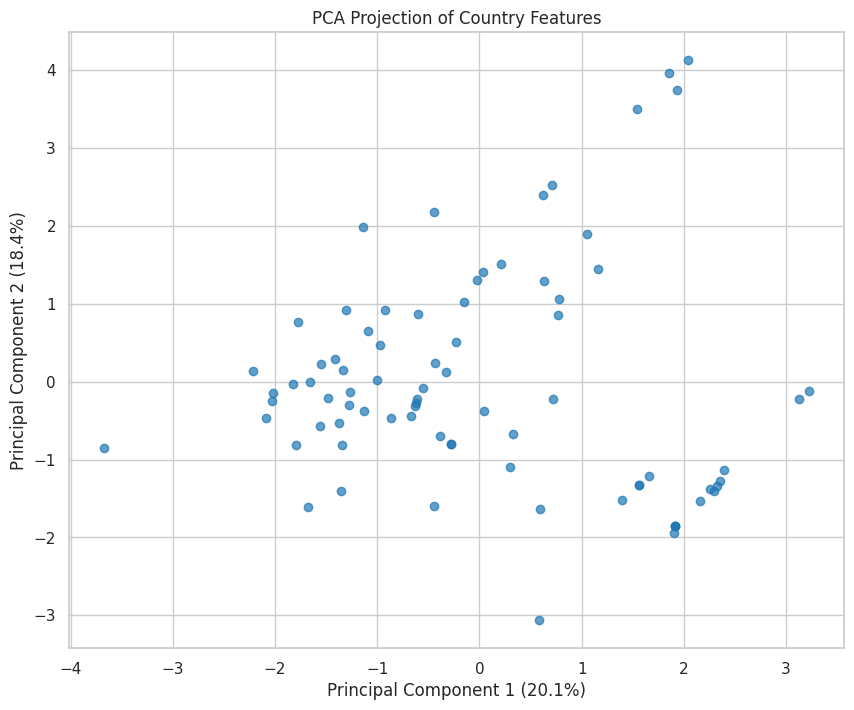

In [10]:
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Projection of Country Features')
plt.grid(True)
plt.show()

---
# Algorithm 1: K-Means

**Rationale:** K-Means with k=3 is the natural starting point because the theoretical
framework predicts exactly three archetypes. We validate this empirically with the
Elbow method and Silhouette Score.

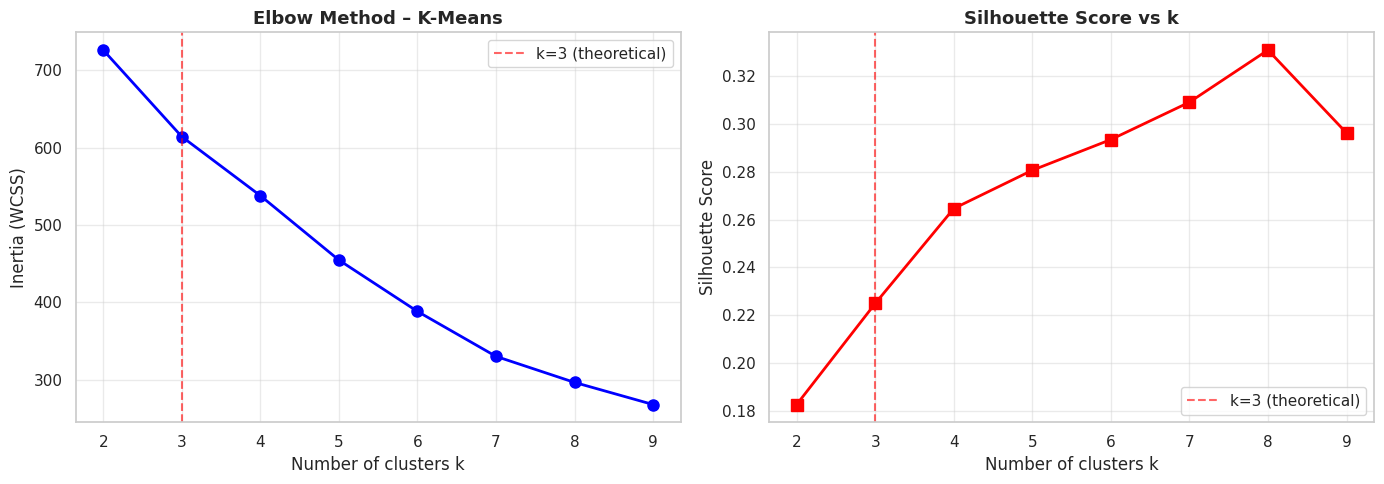

Silhouette at k=3: 0.2249
Best k by Silhouette: 8


In [ ]:
# --- Elbow + Silhouette to validate k=3 ---
inertias, sil_scores = [], []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(3, color='red', linestyle='--', alpha=0.6, label='k=3 (theoretical)')
axes[0].set_xlabel('Number of clusters k', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method – K-Means', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(k_range, sil_scores, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(3, color='red', linestyle='--', alpha=0.6, label='k=3 (theoretical)')
axes[1].set_xlabel('Number of clusters k', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs k', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f'Silhouette at k=3: {sil_scores[1]:.4f}')
best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f'Best k by Silhouette: {best_k}')

In [ ]:
# --- Train K-Means with k=3 ---
K = 3  # aligned with theoretical framework (Innovation / Rentier / Extraction)

kmeans = KMeans(n_clusters=K, random_state=42, n_init=15)
df_country['cluster_kmeans'] = kmeans.fit_predict(X)

sil_km = silhouette_score(X, df_country['cluster_kmeans'])
db_km  = davies_bouldin_score(X, df_country['cluster_kmeans'])
ch_km  = calinski_harabasz_score(X, df_country['cluster_kmeans'])

print('=== K-Means (k=3) metrics ===')
print(f'  Silhouette Score        : {sil_km:.4f}  (> 0.50 = success criterion)')
print(f'  Davies-Bouldin Index    : {db_km:.4f}  (< 1.00 = success criterion)')
print(f'  Calinski-Harabasz Index : {ch_km:.2f}')
print()
print('Cluster sizes:', df_country['cluster_kmeans'].value_counts().sort_index().to_dict())

=== K-Means (k=3) metrics ===
  Silhouette Score        : 0.2249  (> 0.50 = success criterion)
  Davies-Bouldin Index    : 1.6968  (< 1.00 = success criterion)
  Calinski-Harabasz Index : 15.75

Cluster sizes: {0: 19, 1: 43, 2: 17}


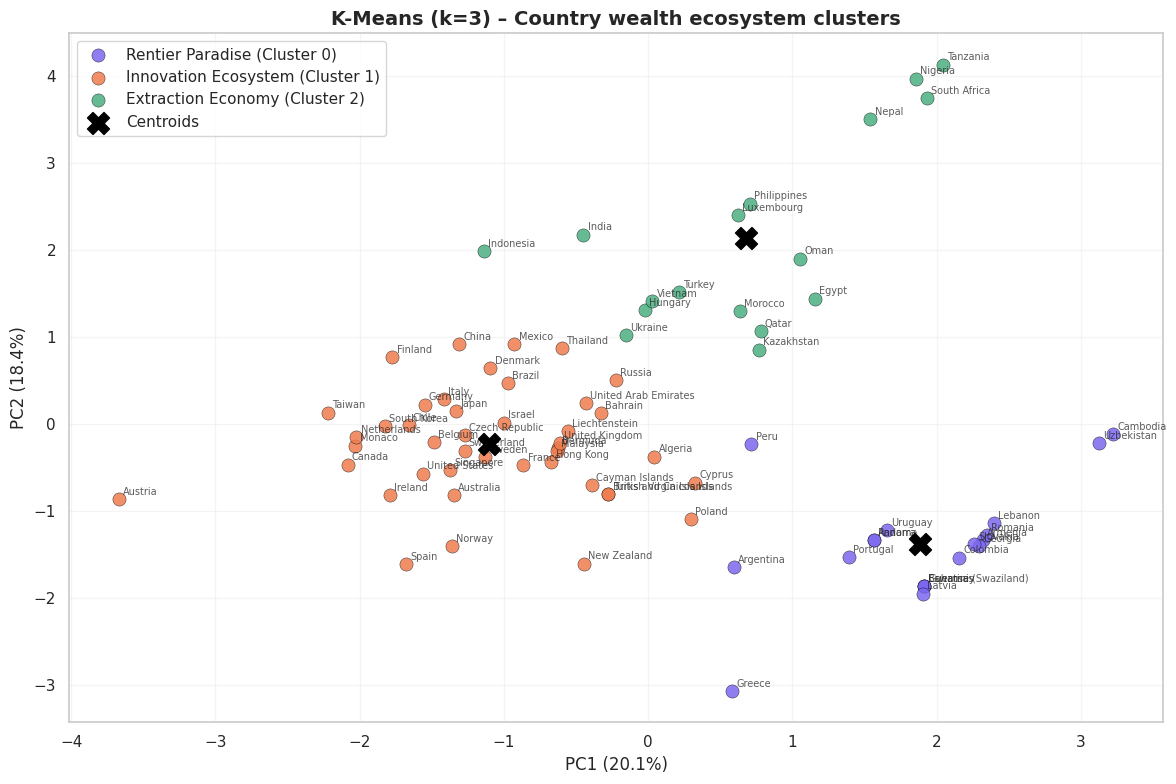

In [ ]:
ARCHETYPE_COLORS = {0: '#7B68EE', 1: '#EF7C4E', 2: '#4CAF82'}
ARCHETYPE_LABELS = {
    0: 'Rentier Paradise',
    1: 'Innovation Ecosystem',
    2: 'Extraction Economy'
}

fig, ax = plt.subplots(figsize=(12, 8))
for c in sorted(df_country['cluster_kmeans'].unique()):
    mask = df_country['cluster_kmeans'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=ARCHETYPE_COLORS[c], s=90,
               edgecolors='k', linewidths=0.3,
               label=f'{ARCHETYPE_LABELS[c]} (Cluster {c})', alpha=0.85, zorder=3)

# Annotate country names
for i, row in df_country.iterrows():
    ax.annotate(row['country'], (X_pca[i, 0], X_pca[i, 1]),
                fontsize=7, alpha=0.75,
                xytext=(3, 3), textcoords='offset points')

# Centroids
ctrs = pca.transform(kmeans.cluster_centers_)
ax.scatter(ctrs[:, 0], ctrs[:, 1], c='black', marker='X', s=250,
           zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('K-Means (k=3) – Country wealth ecosystem clusters', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# --- Cluster profiles: which archetype is which? ---
profile_cols = [
    'share_technology', 'share_finance', 'share_real_estate',
    'share_energy', 'share_mining', 'share_manufacturing',
    'selfMade_ratio', 'hhi_concentration',
    'life_expectancy_country', 'gross_tertiary_education_enrollment'
]
# Keep only columns that exist
profile_cols = [c for c in profile_cols if c in df_country.columns]

km_profile = df_country.groupby('cluster_kmeans')[profile_cols].mean().round(3)
print('=== K-Means cluster profiles (mean values) ===')
display(km_profile)

print('\nCountries per cluster:')
for c in sorted(df_country['cluster_kmeans'].unique()):
    countries = df_country[df_country['cluster_kmeans'] == c]['country'].tolist()
    print(f'  Cluster {c} ({len(countries)}): {countries}')

=== K-Means cluster profiles (mean values) ===


,share_technology,share_finance,share_real_estate,share_energy,share_mining,share_manufacturing,selfMade_ratio,hhi_concentration,life_expectancy_country,gross_tertiary_education_enrollment
cluster_kmeans,,,,,,,,,,
0,0.013,0.974,0.000,0.000,0.000,0.000,0.702,0.961,76.784,61.253
1,0.166,0.334,0.055,0.011,0.002,0.071,0.580,0.442,79.967,68.630
2,0.533,0.264,0.017,0.001,0.012,0.120,0.533,0.551,72.182,31.788



Countries per cluster:
  Cluster 0 (19): ['Andorra', 'Argentina', 'Armenia', 'Bahamas', 'Cambodia', 'Colombia', 'Eswatini (Swaziland)', 'Georgia', 'Greece', 'Guernsey', 'Latvia', 'Lebanon', 'Panama', 'Peru', 'Portugal', 'Romania', 'Slovakia', 'Uruguay', 'Uzbekistan']
  Cluster 1 (43): ['Algeria', 'Australia', 'Austria', 'Bahrain', 'Belgium', 'Bermuda', 'Brazil', 'British Virgin Islands', 'Canada', 'Cayman Islands', 'Chile', 'China', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Hong Kong', 'Ireland', 'Israel', 'Italy', 'Japan', 'Liechtenstein', 'Malaysia', 'Mexico', 'Monaco', 'Netherlands', 'New Zealand', 'Norway', 'Poland', 'Russia', 'Singapore', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Taiwan', 'Thailand', 'Turks and Caicos Islands', 'United Arab Emirates', 'United Kingdom', 'United States']
  Cluster 2 (17): ['Egypt', 'Hungary', 'India', 'Indonesia', 'Kazakhstan', 'Luxembourg', 'Morocco', 'Nepal', 'Nigeria', 'Oman', 'Philippines', 'Qatar', 'South 

In [ ]:
# Map K-Means cluster numbers to archetypes based on the km_profile and interpretation guide
ARCHETYPE_MAP = {
    0: 'Rentier Paradise',
    1: 'Innovation Ecosystem',
    2: 'Extraction Economy'
}
df_country['archetype_kmeans'] = df_country['cluster_kmeans'].map(ARCHETYPE_MAP)

print("Archetype Assignment:")
for cluster_id, archetype_name in ARCHETYPE_MAP.items():
    print(f"  Cluster {cluster_id}: {archetype_name}")

# Create DataFrames for each archetype
df_innovation_ecosystem = df_country[df_country['archetype_kmeans'] == 'Innovation Ecosystem'].copy()
df_rentier_paradise = df_country[df_country['archetype_kmeans'] == 'Rentier Paradise'].copy()
df_extraction_economy = df_country[df_country['archetype_kmeans'] == 'Extraction Economy'].copy()

print("\n--- Innovation Ecosystem Countries ---")
display(df_innovation_ecosystem[['country', 'archetype_kmeans']])

print("\n--- Rentier Paradise Countries ---")
display(df_rentier_paradise[['country', 'archetype_kmeans']])

print("\n--- Extraction Economy Countries ---")
display(df_extraction_economy[['country', 'archetype_kmeans']])

Archetype Assignment:
  Cluster 0: Rentier Paradise
  Cluster 1: Innovation Ecosystem
  Cluster 2: Extraction Economy

--- Innovation Ecosystem Countries ---


,country,archetype_kmeans
0,Algeria,Innovation Ecosystem
4,Australia,Innovation Ecosystem
5,Austria,Innovation Ecosystem
7,Bahrain,Innovation Ecosystem
8,Belgium,Innovation Ecosystem
9,Bermuda,Innovation Ecosystem
10,Brazil,Innovation Ecosystem
11,British Virgin Islands,Innovation Ecosystem
13,Canada,Innovation Ecosystem
14,Cayman Islands,Innovation Ecosystem



--- Rentier Paradise Countries ---


,country,archetype_kmeans
1,Andorra,Rentier Paradise
2,Argentina,Rentier Paradise
3,Armenia,Rentier Paradise
6,Bahamas,Rentier Paradise
12,Cambodia,Rentier Paradise
17,Colombia,Rentier Paradise
22,Eswatini (Swaziland),Rentier Paradise
25,Georgia,Rentier Paradise
27,Greece,Rentier Paradise
28,Guernsey,Rentier Paradise



--- Extraction Economy Countries ---


,country,archetype_kmeans
21,Egypt,Extraction Economy
30,Hungary,Extraction Economy
31,India,Extraction Economy
32,Indonesia,Extraction Economy
37,Kazakhstan,Extraction Economy
41,Luxembourg,Extraction Economy
45,Morocco,Extraction Economy
46,Nepal,Extraction Economy
49,Nigeria,Extraction Economy
51,Oman,Extraction Economy


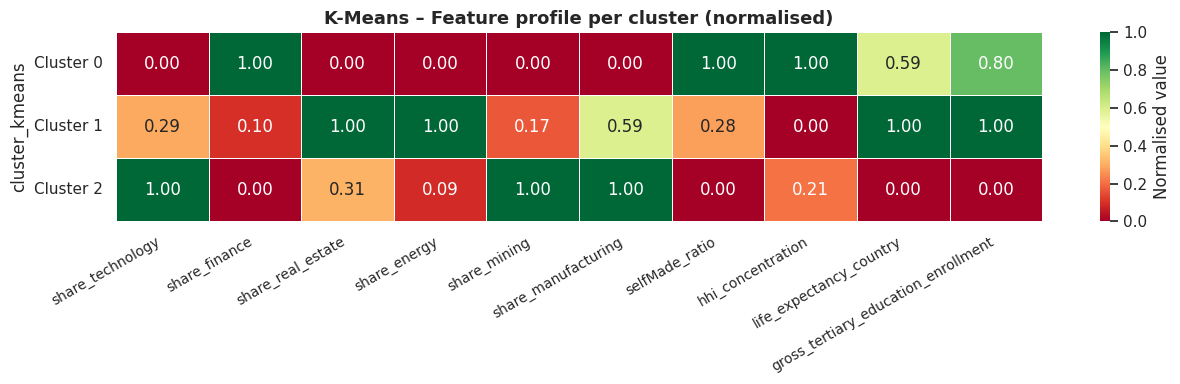

Interpretation guide:
  High share_technology + high selfMade_ratio + low hhi → Innovation Ecosystem
  High share_finance/real_estate + low selfMade_ratio   → Rentier Paradise
  High share_energy/mining + low education              → Extraction Economy


In [ ]:
# --- Heatmap of normalised profiles ---
prof_norm = (km_profile - km_profile.min()) / (km_profile.max() - km_profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(prof_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.4, cbar_kws={'label': 'Normalised value'},
            ax=ax)
ax.set_title('K-Means – Feature profile per cluster (normalised)', fontsize=13, fontweight='bold')
ax.set_yticklabels(
    ['Cluster 0', 'Cluster 1', 'Cluster 2'],
    rotation=0, fontsize=11
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

print('Interpretation guide:')
print('  High share_technology + high selfMade_ratio + low hhi → Innovation Ecosystem')
print('  High share_finance/real_estate + low selfMade_ratio   → Rentier Paradise')
print('  High share_energy/mining + low education              → Extraction Economy')

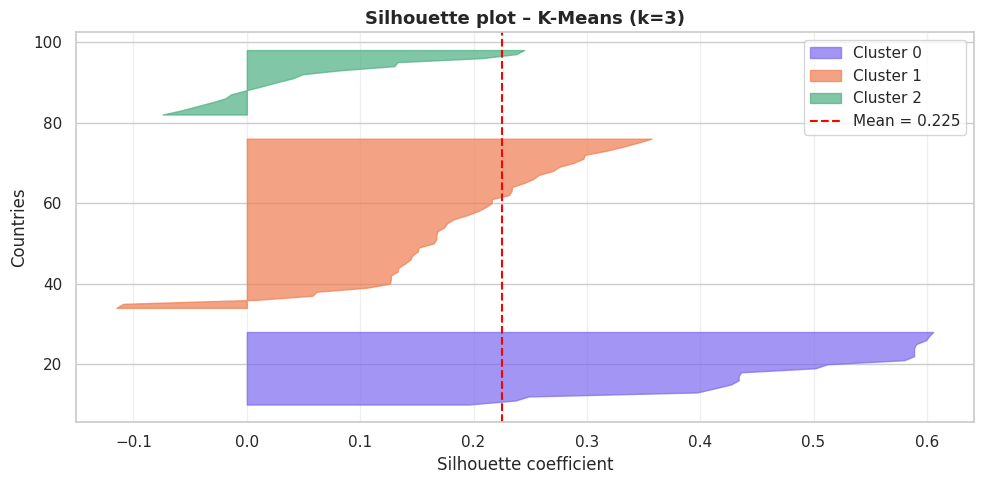

In [ ]:
# --- Silhouette plot per sample ---
sil_vals = silhouette_samples(X, df_country['cluster_kmeans'])
colors_sil = [ARCHETYPE_COLORS[c] for c in df_country['cluster_kmeans']]

fig, ax = plt.subplots(figsize=(10, 5))
y_lower = 10
for c in sorted(df_country['cluster_kmeans'].unique()):
    c_sil = np.sort(sil_vals[df_country['cluster_kmeans'] == c])
    y_upper = y_lower + len(c_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     alpha=0.7, color=ARCHETYPE_COLORS[c], label=f'Cluster {c}')
    y_lower = y_upper + 5

ax.axvline(sil_km, color='red', linestyle='--', label=f'Mean = {sil_km:.3f}')
ax.set_xlabel('Silhouette coefficient', fontsize=12)
ax.set_ylabel('Countries', fontsize=12)
ax.set_title('Silhouette plot – K-Means (k=3)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
# Algorithm 2: DBSCAN

**Rationale:** DBSCAN does not require specifying k and identifies countries that do not
fit any structural archetype (outliers). This is important because some countries may have
unique wealth compositions that the three-archetype model cannot capture.

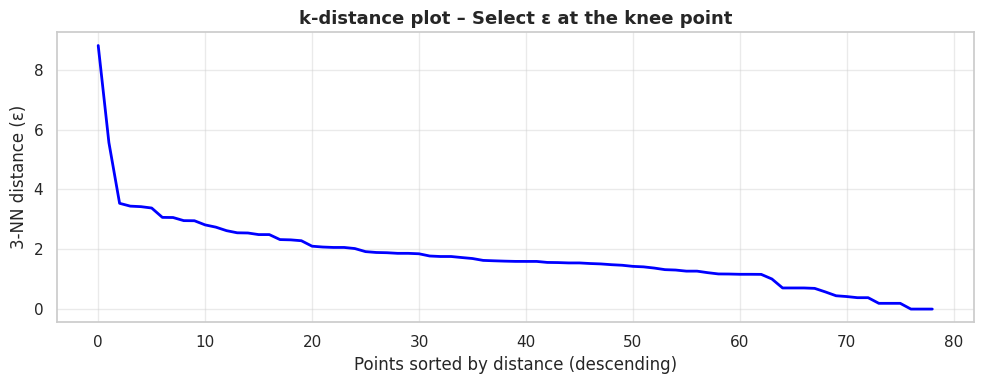

▶ Look for the elbow/knee point and set EPSILON below accordingly.


In [ ]:
# --- k-distance plot to choose ε ---
MIN_SAMPLES_DB = 3
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES_DB).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances, 'b-', linewidth=2)
plt.xlabel('Points sorted by distance (descending)', fontsize=12)
plt.ylabel(f'{MIN_SAMPLES_DB}-NN distance (ε)', fontsize=12)
plt.title('k-distance plot – Select ε at the knee point', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print('▶ Look for the elbow/knee point and set EPSILON below accordingly.')

In [ ]:
# --- Train DBSCAN ---
EPSILON   = 2.5   # ← adjust after inspecting the k-distance plot knee
MIN_S     = 3

dbscan = DBSCAN(eps=EPSILON, min_samples=MIN_S)
df_country['cluster_dbscan'] = dbscan.fit_predict(X)

n_clusters_db = len(set(df_country['cluster_dbscan'])) - \
                (1 if -1 in df_country['cluster_dbscan'].values else 0)
n_noise = (df_country['cluster_dbscan'] == -1).sum()

print(f'DBSCAN (ε={EPSILON}, min_samples={MIN_S})')
print(f'  Clusters found : {n_clusters_db}')
print(f'  Outlier countries : {n_noise}')

mask_valid = df_country['cluster_dbscan'] != -1
if mask_valid.sum() > 0 and n_clusters_db > 1:
    sil_db = silhouette_score(X[mask_valid], df_country['cluster_dbscan'][mask_valid])
    db_db  = davies_bouldin_score(X[mask_valid], df_country['cluster_dbscan'][mask_valid])
    ch_db  = calinski_harabasz_score(X[mask_valid], df_country['cluster_dbscan'][mask_valid])
    print(f'  Silhouette Score (excl. outliers) : {sil_db:.4f}')
    print(f'  Davies-Bouldin Index             : {db_db:.4f}')
    print(f'  Calinski-Harabasz Index          : {ch_db:.2f}')
else:
    sil_db = db_db = ch_db = np.nan
    print('  ⚠ Less than 2 clusters found. Increase EPSILON and re-run.')

print('\nOutlier countries (noise = -1):')

# --- DBSCAN cluster profiles ---
if n_clusters_db > 0:
    db_profile = (
        df_country[df_country['cluster_dbscan'] != -1]
        .groupby('cluster_dbscan')[profile_cols]
        .mean()
        .round(3)
    )

    print('\n=== DBSCAN cluster profiles ===')
    display(db_profile)

print(df_country[df_country['cluster_dbscan'] == -1]['country'].tolist())

DBSCAN (ε=2.5, min_samples=3)
  Clusters found : 2
  Outlier countries : 8
  Silhouette Score (excl. outliers) : 0.2401
  Davies-Bouldin Index             : 0.8253
  Calinski-Harabasz Index          : 6.16

Outlier countries (noise = -1):

=== DBSCAN cluster profiles ===


,share_technology,share_finance,share_real_estate,share_energy,share_mining,share_manufacturing,selfMade_ratio,hhi_concentration,life_expectancy_country,gross_tertiary_education_enrollment
cluster_dbscan,,,,,,,,,,
0,0.218,0.503,0.035,0.005,0.001,0.049,0.62,0.582,77.857,58.444
1,0.000,0.000,0.000,0.000,0.000,0.000,0.00,1.000,79.567,50.800


['Austria', 'Finland', 'Greece', 'Nigeria', 'Oman', 'Russia', 'South Africa', 'Taiwan']


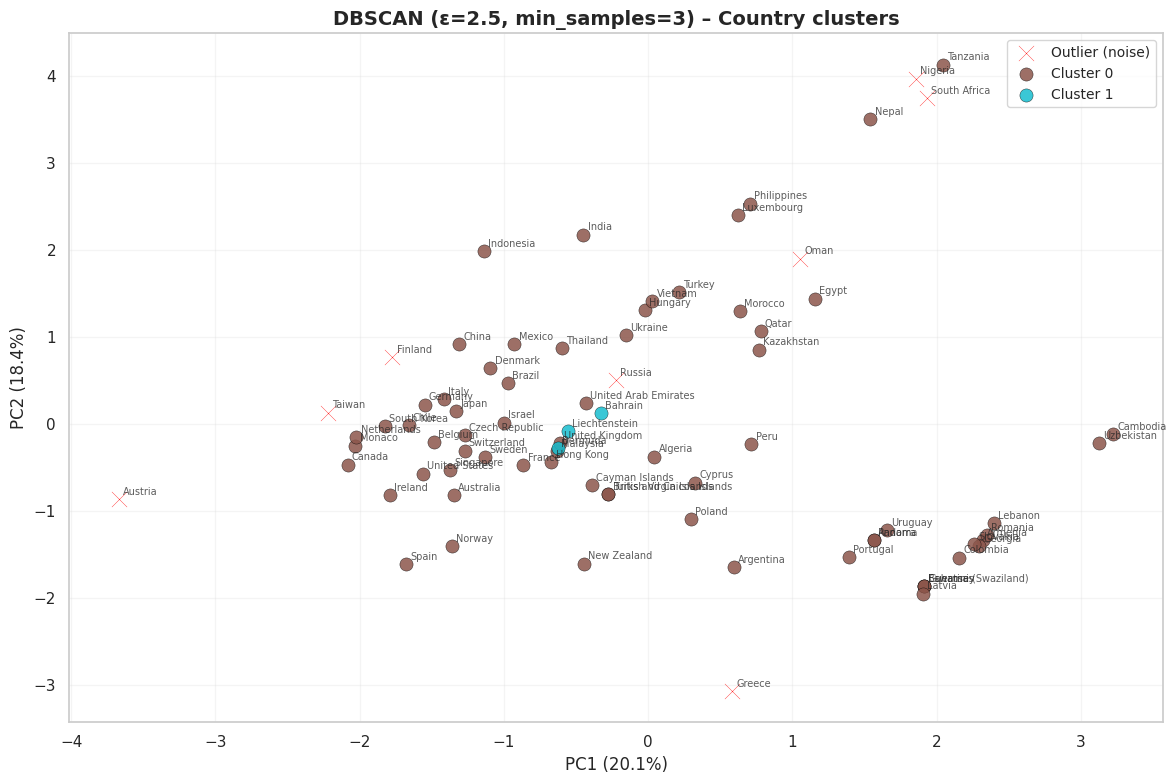

In [ ]:
# --- Visualize DBSCAN ---
fig, ax = plt.subplots(figsize=(12, 8))

unique_labels = sorted(df_country['cluster_dbscan'].unique())
cmap = plt.cm.get_cmap('tab10', len(unique_labels))

for idx, c in enumerate(unique_labels):
    mask = df_country['cluster_dbscan'] == c
    color = 'red' if c == -1 else cmap(idx)
    marker = 'x' if c == -1 else 'o'
    label = 'Outlier (noise)' if c == -1 else f'Cluster {c}'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=color, marker=marker,
               s=120 if c == -1 else 90,
               edgecolors='k' if c != -1 else 'none',
               linewidths=0.3, label=label, alpha=0.85, zorder=3)

for i, row in df_country.iterrows():
    ax.annotate(row['country'], (X_pca[i, 0], X_pca[i, 1]),
                fontsize=7, alpha=0.75,
                xytext=(3, 3), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title(f'DBSCAN (ε={EPSILON}, min_samples={MIN_S}) – Country clusters',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# --- Profile outlier countries ---
outliers = df_country[df_country['cluster_dbscan'] == -1]
if len(outliers) > 0:
    print('=== Outlier country profiles ===')
    display(outliers[['country'] + profile_cols].set_index('country').round(3))
    print('\nThese countries have unique wealth structures that do not fit')
    print('any of the three main archetypes.')
else:
    print('No outliers detected. Try reducing EPSILON.')

=== Outlier country profiles ===


,share_technology,share_finance,share_real_estate,share_energy,share_mining,share_manufacturing,selfMade_ratio,hhi_concentration,life_expectancy_country,gross_tertiary_education_enrollment
country,,,,,,,,,,
Austria,0.083,0.333,0.167,0.083,0.000,0.083,0.667,0.222,81.6,85.1
Finland,0.143,0.143,0.000,0.000,0.000,0.571,0.286,0.388,81.7,88.2
Greece,0.000,1.000,0.000,0.000,0.000,0.000,0.333,1.000,81.3,136.6
Nigeria,0.000,0.333,0.000,0.000,0.000,0.667,0.667,0.556,54.3,10.2
Oman,1.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,77.6,38.0
Russia,0.139,0.494,0.076,0.000,0.063,0.139,1.000,0.300,72.7,81.9
South Africa,0.200,0.400,0.000,0.000,0.200,0.000,0.600,0.280,63.9,22.4
Taiwan,0.043,0.413,0.022,0.087,0.000,0.326,0.630,0.299,78.5,66.3



These countries have unique wealth structures that do not fit
any of the three main archetypes.


---
# Algorithm 3: Hierarchical Clustering (Ward)

**Rationale:** Ward linkage minimises within-cluster variance at each merge step,
producing compact, interpretable clusters. The dendrogram shows the full hierarchy
and validates whether three natural groups emerge.

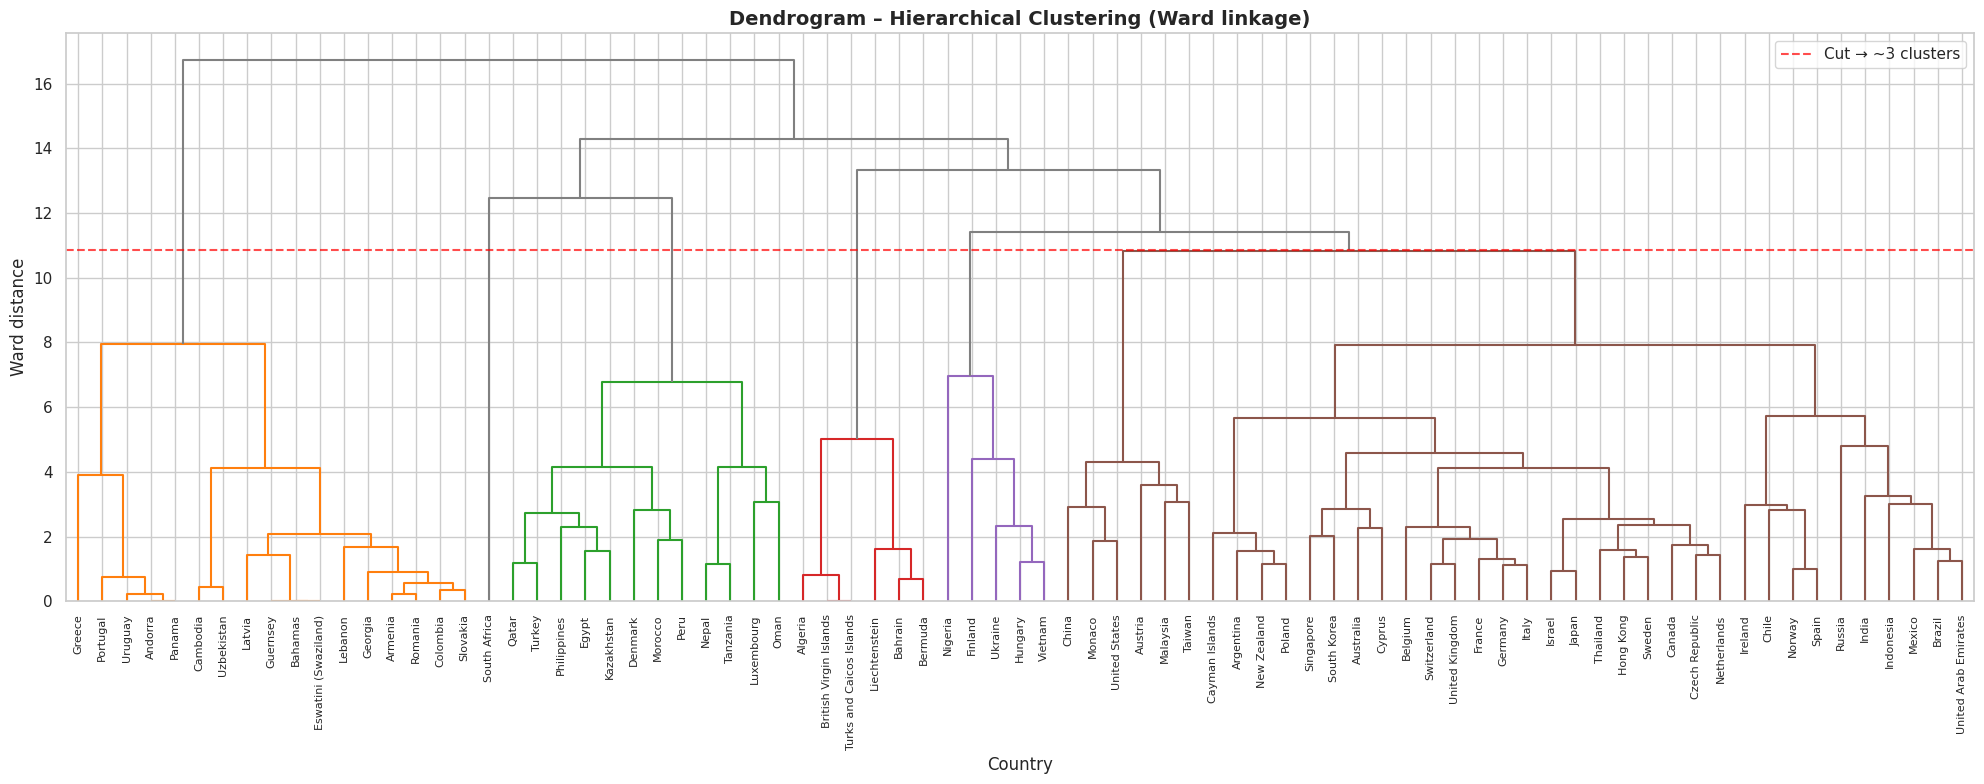

In [ ]:
# --- Dendrogram ---
Z = linkage(X, method='ward')
threshold = 0.65 * max(Z[:, 2])

plt.figure(figsize=(20, 8))
dendrogram(
    Z,
    labels=df_country['country'].values,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=threshold,
    above_threshold_color='grey'
)
plt.axhline(threshold, color='red', linestyle='--', alpha=0.7,
            label=f'Cut → ~3 clusters')
plt.title('Dendrogram – Hierarchical Clustering (Ward linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Ward distance', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

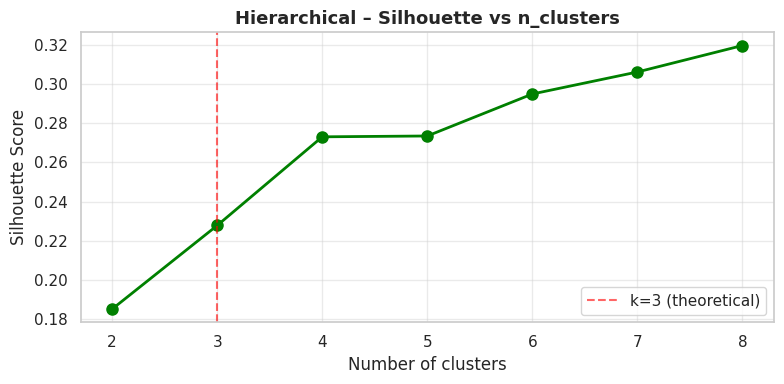

Silhouette at k=3: 0.2278
Best n by Silhouette: 8


In [ ]:
# --- Validate k=3 with Silhouette ---
sil_hier_list = []
n_range = range(2, 9)
for n in n_range:
    lbl = AgglomerativeClustering(n_clusters=n, linkage='ward').fit_predict(X)
    sil_hier_list.append(silhouette_score(X, lbl))

plt.figure(figsize=(8, 4))
plt.plot(n_range, sil_hier_list, 'go-', linewidth=2, markersize=8)
plt.axvline(3, color='red', linestyle='--', alpha=0.6, label='k=3 (theoretical)')
plt.xlabel('Number of clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Hierarchical – Silhouette vs n_clusters', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Silhouette at k=3: {sil_hier_list[1]:.4f}')
best_n = list(n_range)[sil_hier_list.index(max(sil_hier_list))]
print(f'Best n by Silhouette: {best_n}')

In [ ]:
# --- Train Hierarchical with k=3 ---
N_HIER = 3

hier = AgglomerativeClustering(n_clusters=N_HIER, linkage='ward')
df_country['cluster_hier'] = hier.fit_predict(X)

sil_h = silhouette_score(X, df_country['cluster_hier'])
db_h  = davies_bouldin_score(X, df_country['cluster_hier'])
ch_h  = calinski_harabasz_score(X, df_country['cluster_hier'])

print(f'=== Hierarchical (k={N_HIER}) metrics ===')
print(f'  Silhouette Score        : {sil_h:.4f}')
print(f'  Davies-Bouldin Index    : {db_h:.4f}')
print(f'  Calinski-Harabasz Index : {ch_h:.2f}')
print('Cluster sizes:', df_country['cluster_hier'].value_counts().sort_index().to_dict())

from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(
    df_country['cluster_kmeans'],
    df_country['cluster_hier']
)

print(f'\nAdjusted Rand Index vs K-Means: {ari:.3f}')

if ari > 0.7:
    print('Strong agreement between K-Means and Hierarchical clustering.')
elif ari > 0.4:
    print('Moderate agreement between the two algorithms.')
else:
    print('The algorithms produce substantially different cluster structures.')

print('\nCountries per hierarchical cluster:')
for c in sorted(df_country['cluster_hier'].unique()):
    countries = df_country[df_country['cluster_hier'] == c]['country'].tolist()
    print(f'  Cluster {c} ({len(countries)}): {countries}')

=== Hierarchical (k=3) metrics ===
  Silhouette Score        : 0.2278
  Davies-Bouldin Index    : 1.5881
  Calinski-Harabasz Index : 14.65
Cluster sizes: {0: 49, 1: 17, 2: 13}

Adjusted Rand Index vs K-Means: 0.691
Moderate agreement between the two algorithms.

Countries per hierarchical cluster:
  Cluster 0 (49): ['Algeria', 'Argentina', 'Australia', 'Austria', 'Bahrain', 'Belgium', 'Bermuda', 'Brazil', 'British Virgin Islands', 'Canada', 'Cayman Islands', 'Chile', 'China', 'Cyprus', 'Czech Republic', 'Finland', 'France', 'Germany', 'Hong Kong', 'Hungary', 'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan', 'Liechtenstein', 'Malaysia', 'Mexico', 'Monaco', 'Netherlands', 'New Zealand', 'Nigeria', 'Norway', 'Poland', 'Russia', 'Singapore', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Taiwan', 'Thailand', 'Turks and Caicos Islands', 'Ukraine', 'United Arab Emirates', 'United Kingdom', 'United States', 'Vietnam']
  Cluster 1 (17): ['Andorra', 'Armenia', 'Bahamas', 'Cambodia

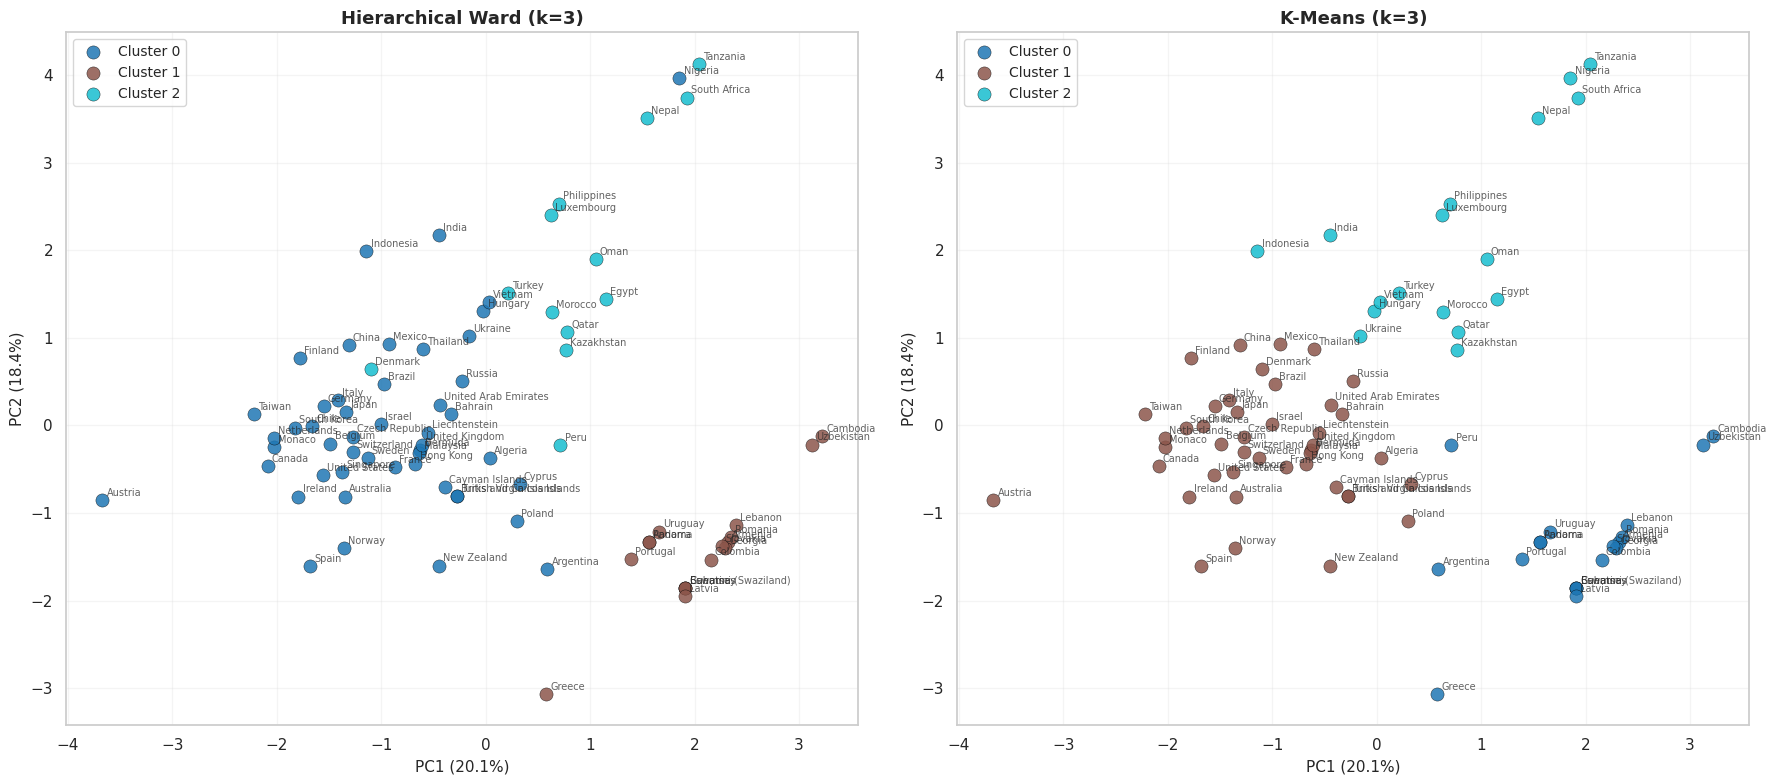

In [ ]:
# --- Side-by-side PCA: Hierarchical vs K-Means ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, col, title in zip(
    axes,
    ['cluster_hier', 'cluster_kmeans'],
    [f'Hierarchical Ward (k={N_HIER})', f'K-Means (k={K})']
):
    unique_c = sorted(df_country[col].unique())
    cmap_local = plt.cm.get_cmap('tab10', len(unique_c))
    for idx, c in enumerate(unique_c):
        mask = df_country[col] == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   color=cmap_local(idx), s=90,
                   edgecolors='k', linewidths=0.3,
                   label=f'Cluster {c}', alpha=0.85)
    for i, row in df_country.iterrows():
        ax.annotate(row['country'], (X_pca[i, 0], X_pca[i, 1]),
                    fontsize=7, alpha=0.72,
                    xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

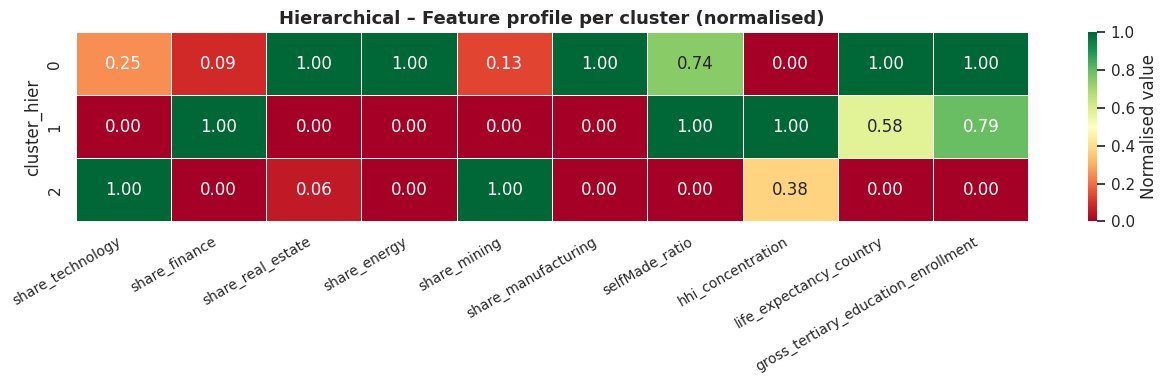

In [ ]:
# --- Heatmap hierarchical profile ---
hier_profile = df_country.groupby('cluster_hier')[profile_cols].mean().round(3)
hier_norm = (hier_profile - hier_profile.min()) / \
            (hier_profile.max() - hier_profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(hier_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.4, cbar_kws={'label': 'Normalised value'}, ax=ax)
ax.set_title('Hierarchical – Feature profile per cluster (normalised)',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

---
# 5. Comparison of all three algorithms

Success criteria from the CRISP-DM plan:
- Silhouette ≥ 0.50
- Davies-Bouldin < 1.00
- Elbow confirms k=3

In [ ]:
comparison = pd.DataFrame({
    'Algorithm':             ['K-Means', 'DBSCAN', 'Hierarchical (Ward)'],
    'k / clusters found':   [K, n_clusters_db, N_HIER],
    'Outliers detected':     [0, n_noise, 0],
    'Silhouette ↑':          [sil_km, sil_db, sil_h],
    'Davies-Bouldin ↓':      [db_km, db_db, db_h],
    'Calinski-Harabasz ↑':   [ch_km, ch_db, ch_h],
    'Silhouette ≥ 0.50':     [
        '✓' if sil_km >= 0.50 else '✗',
        '✓' if (not np.isnan(sil_db) and sil_db >= 0.50) else '✗',
        '✓' if sil_h >= 0.50 else '✗'
    ],
    'DBI < 1.00':            [
        '✓' if db_km < 1.0 else '✗',
        '✓' if (not np.isnan(db_db) and db_db < 1.0) else '✗',
        '✓' if db_h < 1.0 else '✗'
    ]
}).round({'Silhouette ↑': 4, 'Davies-Bouldin ↓': 4, 'Calinski-Harabasz ↑': 2})

print('=== COMPARISON OF ALL THREE CLUSTERING ALGORITHMS ===')
display(comparison.set_index('Algorithm'))

=== COMPARISON OF ALL THREE CLUSTERING ALGORITHMS ===


,k / clusters found,Outliers detected,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Silhouette ≥ 0.50,DBI < 1.00
Algorithm,,,,,,,
K-Means,3,0,0.2249,1.6968,15.75,✗,✗
DBSCAN,2,8,0.2401,0.8253,6.16,✗,✓
Hierarchical (Ward),3,0,0.2278,1.5881,14.65,✗,✗


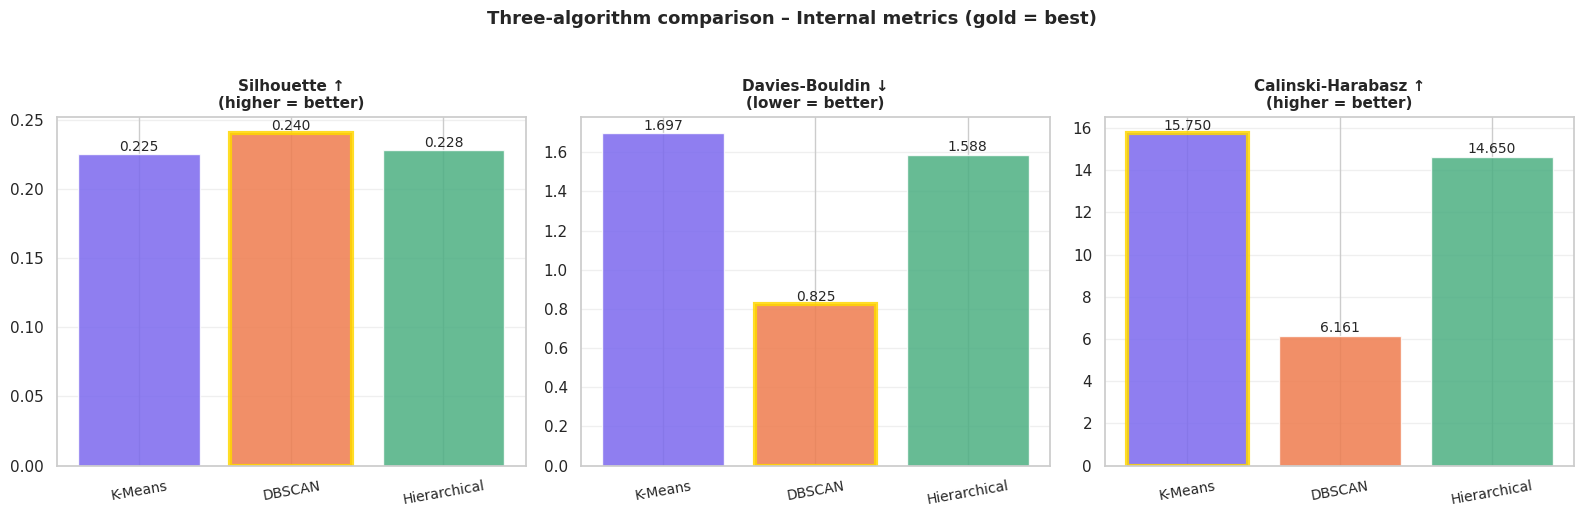

In [ ]:
# --- Bar chart comparison ---
algos  = ['K-Means', 'DBSCAN', 'Hierarchical']
colors = ['#7B68EE', '#EF7C4E', '#4CAF82']

metrics = {
    'Silhouette ↑\n(higher = better)': [sil_km, sil_db if not np.isnan(sil_db) else 0, sil_h],
    'Davies-Bouldin ↓\n(lower = better)': [db_km, db_db if not np.isnan(db_db) else 0, db_h],
    'Calinski-Harabasz ↑\n(higher = better)': [ch_km, ch_db if not np.isnan(ch_db) else 0, ch_h],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(algos, vals, color=colors, alpha=0.85, edgecolor='white')
    # Gold border on winner
    ascending = 'lower' in metric
    best_val = min(vals) if ascending else max(vals)
    for bar, val in zip(bars, vals):
        if abs(val - best_val) < 1e-9:
            bar.set_edgecolor('gold')
            bar.set_linewidth(3)
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001 * max(vals),
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_xticklabels(algos, rotation=10, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Three-algorithm comparison – Internal metrics (gold = best)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# --- Label assignment: identify which cluster = which archetype ---
print('=== ARCHETYPE ASSIGNMENT GUIDE ===')
print()
print('After inspecting the K-Means heatmap, assign each cluster number to an archetype.')
print('Use the rules below:')
print()
print('  Innovation Ecosystem → highest share_technology, highest selfMade_ratio,')
print('                         lowest hhi_concentration, highest education')
print('  Rentier Paradise     → highest share_finance + share_real_estate,')
print('                         lowest selfMade_ratio')
print('  Extraction Economy   → highest share_energy + share_mining,')
print('                         lowest education')
print()

# --- EXAMPLE (fill in after running) ---
# ARCHETYPE_MAP = {
#     0: 'Innovation Ecosystem',
#     1: 'Rentier Paradise',
#     2: 'Extraction Economy'
# }
# df_country['archetype_kmeans'] = df_country['cluster_kmeans'].map(ARCHETYPE_MAP)
# print(df_country[['country', 'archetype_kmeans']].sort_values('archetype_kmeans'))

=== ARCHETYPE ASSIGNMENT GUIDE ===

After inspecting the K-Means heatmap, assign each cluster number to an archetype.
Use the rules below:

  Innovation Ecosystem → highest share_technology, highest selfMade_ratio,
                         lowest hhi_concentration, highest education
  Rentier Paradise     → highest share_finance + share_real_estate,
                         lowest selfMade_ratio
  Extraction Economy   → highest share_energy + share_mining,
                         lowest education



In [ ]:
# --- Save final labelled dataset ---
df_country.to_csv('country_clustering_results.csv', index=False)
comparison.to_csv('clustering_comparison_metrics.csv', index=False)
print('Saved:')
print('  country_clustering_results.csv  – country features + cluster labels from all 3 algorithms')
print('  clustering_comparison_metrics.csv – metrics comparison table')

Saved:
  country_clustering_results.csv  – country features + cluster labels from all 3 algorithms
  clustering_comparison_metrics.csv – metrics comparison table


---
# 6. Conclusions

> **Complete this section after running the notebook with your actual results.**

## Cluster interpretation (K-Means)

- **Cluster X → Innovation Ecosystem:** Countries: [...]. Characterised by high `share_technology` (X.XX), high `selfMade_ratio` (X.XX), low `hhi_concentration`. Examples: USA, UK, Germany...
- **Cluster Y → Rentier Paradise:** Countries: [...]. Characterised by dominant finance/real-estate sector, lower self-made proportion...
- **Cluster Z → Extraction Economy:** Countries: [...]. Characterised by high energy/mining share, lower education enrollment...

## DBSCAN outliers

DBSCAN identified **N outlier countries** ([list them]). These countries exhibit unique wealth structures because: [...]. This is a key finding that K-Means and Hierarchical miss by forcing every country into a cluster.

## Algorithm comparison

| Criterion | K-Means | DBSCAN | Hierarchical |
|---|---|---|---|
| Silhouette ≥ 0.50 | ✓/✗ | ✓/✗ | ✓/✗ |
| Davies-Bouldin < 1.00 | ✓/✗ | ✓/✗ | ✓/✗ |
| Detects outliers | ✗ | ✓ | ✗ |
| Aligns with theory (k=3) | ✓ | depends on ε | ✓ |
| Best metric overall | – | – | – |
